<a href="https://colab.research.google.com/github/StaryDron/PigPostureComputerVision/blob/main/Convnext_Augmentacja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── Instalacja ─────────────────────────────────────────────────────────────────
!pip install albumentations timm -q

# ── Kaggle API ────────────────────────────────────────────────────────────────
from google.colab import files
files.upload()

import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle competitions download -c multi-view-pig-posture-recognition
!unzip multi-view-pig-posture-recognition.zip
!ls

# ── Importy ───────────────────────────────────────────────────────────────────
import os, ast, copy, re, time
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
import torchvision.transforms.functional as TF

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ── GPU ───────────────────────────────────────────────────────────────────────
torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    _ = torch.zeros(1).cuda(); torch.cuda.synchronize()
    x = torch.randn(10000, 10000, device="cuda")
    t0 = time.time(); _ = x @ x; torch.cuda.synchronize()
    elapsed = time.time() - t0
    print(f"GPU test: {elapsed:.3f}s  {'✓ ok' if elapsed < 1.0 else '⚠ wolno'}")
    del x; torch.cuda.empty_cache()

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_141300.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_141439.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_141759.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_141940.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_142300.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_142441.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_142801.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_142941.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/pen1_tur_cam2_20250207_143301.jpg  
  inflating: multiview_pig_posture_recognition/train1_images/p

In [ ]:
!ls

data  multi-view-pig-posture-recognition.zip  sample_data


In [ ]:
CLASS_NAMES = {
    0: "Lateral_lying_left",
    1: "Lateral_lying_right",
    2: "Sitting",
    3: "Standing",
    4: "Sternal_lying",
}
NUM_CLASSES = len(CLASS_NAMES)

BASE_DIR    = Path("multiview_pig_posture_recognition")
TRAIN2_IMGS = BASE_DIR / "train2_images"
TEST_IMGS   = BASE_DIR / "test_images"

BATCH_SIZE = 32
EPOCHS     = 6
SAVE_PATH  = "T2_convnextv2_fcmae_camera_aug.pt"

print("Stałe ok ✓")

Stałe ok ✓


In [ ]:
import re

def parse_camera_meta(image_id):
    m = re.match(r"(pen\d+)_(orb|tur)_(cam\d+)_", image_id)
    if m:
        return m.group(1), m.group(2), m.group(3)
    return "unknown", "unknown", "unknown"

def add_camera_cols(df):
    df["pen"]      = df["image_id"].apply(lambda x: parse_camera_meta(x)[0])
    df["cam_type"] = df["image_id"].apply(lambda x: parse_camera_meta(x)[1])
    df["cam_num"]  = df["image_id"].apply(lambda x: parse_camera_meta(x)[2])
    df["camera"]   = df["pen"] + "_" + df["cam_type"] + "_" + df["cam_num"]
    return df

train2 = pd.read_csv(BASE_DIR / "train2.csv")
train2["source"]      = "train2"
train2["bbox_parsed"] = train2["bbox"].apply(ast.literal_eval)
train2["class_name"]  = train2["class_id"].map(CLASS_NAMES)
train2 = add_camera_cols(train2)

print(f"Train2: {len(train2):,} obs  |  {train2['image_id'].nunique():,} zdjęć")
print("\nRozkład klas:")
print(train2["class_name"].value_counts().to_string())
print("\nRozkład kamer:")
print(train2.groupby("camera")["image_id"].count().sort_values(ascending=False).to_string())

Train2: 23,450 obs  |  3,150 zdjęć

Rozkład klas:
class_name
Standing               9928
Sternal_lying          6309
Lateral_lying_right    3435
Lateral_lying_left     3083
Sitting                 695

Rozkład kamer:
camera
pen2_tur_cam1    9713
pen1_tur_cam2    8194
pen2_orb_cam1    2817
pen1_orb_cam2    1488
pen1_orb_cam1     722
pen1_tur_cam1     200
pen2_tur_cam2     196
pen2_orb_cam2     120


In [ ]:
def load_image(image_id, source):
    folder = {"train2": TRAIN2_IMGS, "test": TEST_IMGS}[source]
    return Image.open(folder / image_id).convert("RGB")


def crop_with_padding(image, bbox, padding=0.12, make_square=True):
    """bbox = [x_topleft, y_topleft, w, h]"""
    img_w, img_h = image.size
    x, y, w, h   = map(float, bbox)
    x1 = x - w * padding;      y1 = y - h * padding
    x2 = x + w + w * padding;  y2 = y + h + h * padding
    if make_square:
        side   = max(x2 - x1, y2 - y1)
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        x1, x2, y1, y2 = cx - side/2, cx + side/2, cy - side/2, cy + side/2
    x1 = max(0, int(round(x1)));      y1 = max(0, int(round(y1)))
    x2 = min(img_w, int(round(x2)));  y2 = min(img_h, int(round(y2)))
    return image.crop((max(x1, 0), max(y1, 0), max(x2, x1+1), max(y2, y1+1)))

In [ ]:
# ── Mapowanie labeli po flipie poziomym ───────────────────────────────────────
FLIP_LABEL_MAP = {0: 1, 1: 0, 2: 2, 3: 3, 4: 4}

# ── Funkcje augmentacji (PIL → PIL) ──────────────────────────────────────────

def aug_pen2_tur_cam1(img):
    """Flip poziomy + lekkie schłodzenie koloru."""
    img = TF.hflip(img)
    img = TF.adjust_saturation(img, saturation_factor=0.8)
    img = TF.adjust_brightness(img, brightness_factor=0.95)
    return img

def aug_pen1_tur_cam2(img):
    """Flip poziomy + rozjaśnienie + lekka desaturacja."""
    img = TF.hflip(img)
    img = TF.adjust_brightness(img, brightness_factor=1.35)
    img = TF.adjust_saturation(img, saturation_factor=0.9)
    return img

def aug_pen2_orb_cam1(img):
    """Flip poziomy + przyciemnienie + kontrast + zielonkawy shift + greyscale."""
    img = TF.hflip(img)
    img = TF.adjust_brightness(img, brightness_factor=0.6)
    img = TF.adjust_contrast(img, contrast_factor=1.5)
    img_np = np.array(img).astype(float)
    img_np[:, :, 0] = (img_np[:, :, 0] * 0.85).clip(0, 255)  # mniej czerwonego
    img_np[:, :, 1] = (img_np[:, :, 1] * 1.10).clip(0, 255)  # więcej zielonego
    img_np[:, :, 2] = (img_np[:, :, 2] * 0.80).clip(0, 255)  # mniej niebieskiego
    img_shifted = Image.fromarray(img_np.clip(0, 255).astype(np.uint8))
    img_grey    = TF.to_grayscale(img_shifted, num_output_channels=3)
    grey_np     = np.array(img_grey).astype(float)
    blended     = (0.65 * img_np + 0.35 * grey_np).clip(0, 255).astype(np.uint8)
    return Image.fromarray(blended)

def aug_pen2_tur_cam2(img):
    """Rozjaśnienie + lekka desaturacja."""
    img = TF.adjust_brightness(img, brightness_factor=1.3)
    img = TF.adjust_saturation(img, saturation_factor=0.85)
    return img

def aug_pen2_orb_cam2(img):
    """Przyciemnienie + kontrast + greyscale."""
    img = TF.adjust_brightness(img, brightness_factor=0.60)
    img = TF.adjust_contrast(img, contrast_factor=1.5)
    img_grey = TF.to_grayscale(img, num_output_channels=3)
    img_np   = np.array(img).astype(float)
    grey_np  = np.array(img_grey).astype(float)
    blended  = (0.65 * img_np + 0.35 * grey_np).clip(0, 255).astype(np.uint8)
    return Image.fromarray(blended)

# pen1_orb_cam1, pen1_orb_cam2 — bez augmentacji (brak odpowiednika w teście)

CAMERA_AUG_FN = {
    "pen2_tur_cam1": (aug_pen2_tur_cam1, True),
    "pen1_tur_cam2": (aug_pen1_tur_cam2, True),
    "pen2_orb_cam1": (aug_pen2_orb_cam1, True),
    "pen2_tur_cam2": (aug_pen2_tur_cam2, False),
    "pen2_orb_cam2": (aug_pen2_orb_cam2, False),
}

print("Augmentacje per kamera zdefiniowane ✓")
for cam, (fn, flip) in CAMERA_AUG_FN.items():
    print(f"  {cam:20s}  flip_label={flip}")

Augmentacje per kamera zdefiniowane ✓
  pen2_tur_cam1         flip_label=True
  pen1_tur_cam2         flip_label=True
  pen2_orb_cam1         flip_label=True
  pen2_tur_cam2         flip_label=False
  pen2_orb_cam2         flip_label=False


In [ ]:
class AddGaussianNoise:
    def __init__(self, std=0.02, p=0.15):
        self.std, self.p = std, p
    def __call__(self, tensor):
        if torch.rand(1).item() < self.p:
            tensor = torch.clamp(
                tensor + torch.randn_like(tensor) * self.std, 0., 1.)
        return tensor


# Końcowy transform (resize + normalize) — wspólny dla wszystkich
BASE_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    AddGaussianNoise(std=0.02, p=0.15),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

VAL_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


class PigDatasetCameraAug(Dataset):
    """
    Dataset który dla każdej obserwacji zwraca:
    - oryginalne zdjęcie (po BASE_TRANSFORM)
    - jeśli kamera ma augmentację: dodatkowo zaugmentowaną wersję
      z poprawionym labelem (flip_label jeśli kamera ma flip)

    Efektywnie podwaja lub zostawia bez zmian liczbę obserwacji
    zależnie od kamery.
    """
    def __init__(self, df, camera_aug_fn, base_transform, is_train=True):
        self.base_transform  = base_transform
        self.camera_aug_fn   = camera_aug_fn
        self.is_train        = is_train

        # Budujemy listę (row_idx, augmented, new_label)
        self.samples = []
        df = df.reset_index(drop=True)
        self.df = df

        for idx, row in df.iterrows():
            cam   = row.get("camera", "unknown")
            label = int(row["class_id"])

            # Zawsze dodajemy oryginał
            self.samples.append((idx, False, label))

            # Jeśli kamera ma augmentację — dodajemy zaugmentowaną wersję
            if is_train and cam in camera_aug_fn:
                _, flip_label = camera_aug_fn[cam]
                new_label = FLIP_LABEL_MAP[label] if flip_label else label
                self.samples.append((idx, True, new_label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        row_idx, do_aug, label = self.samples[idx]
        row   = self.df.iloc[row_idx]
        image = load_image(row["image_id"], row["source"])
        crop  = crop_with_padding(image, row["bbox_parsed"],
                                  padding=0.12, make_square=True)

        if do_aug:
            cam    = row["camera"]
            aug_fn, _ = self.camera_aug_fn[cam]
            crop   = aug_fn(crop)

        crop = self.base_transform(crop)
        return crop, label


train_dataset = PigDatasetCameraAug(
    train2, CAMERA_AUG_FN, BASE_TRANSFORM, is_train=True
)

print(f"Obserwacji w train2:        {len(train2):,}")
print(f"Obserwacji po augmentacji:  {len(train_dataset):,}  "
      f"(×{len(train_dataset)/len(train2):.2f})")
print("\nSprawdzenie rozkładu labeli po augmentacji:")
aug_labels = [train_dataset[i][1] for i in range(min(1000, len(train_dataset)))]
from collections import Counter
label_counts = Counter(aug_labels)
for cid, cnt in sorted(label_counts.items()):
    print(f"  {CLASS_NAMES[cid]:25s}: {cnt}")

Obserwacji w train2:        23,450
Obserwacji po augmentacji:  44,490  (×1.90)

Sprawdzenie rozkładu labeli po augmentacji:
  Lateral_lying_left       : 242
  Lateral_lying_right      : 199
  Standing                 : 246
  Sternal_lying            : 313


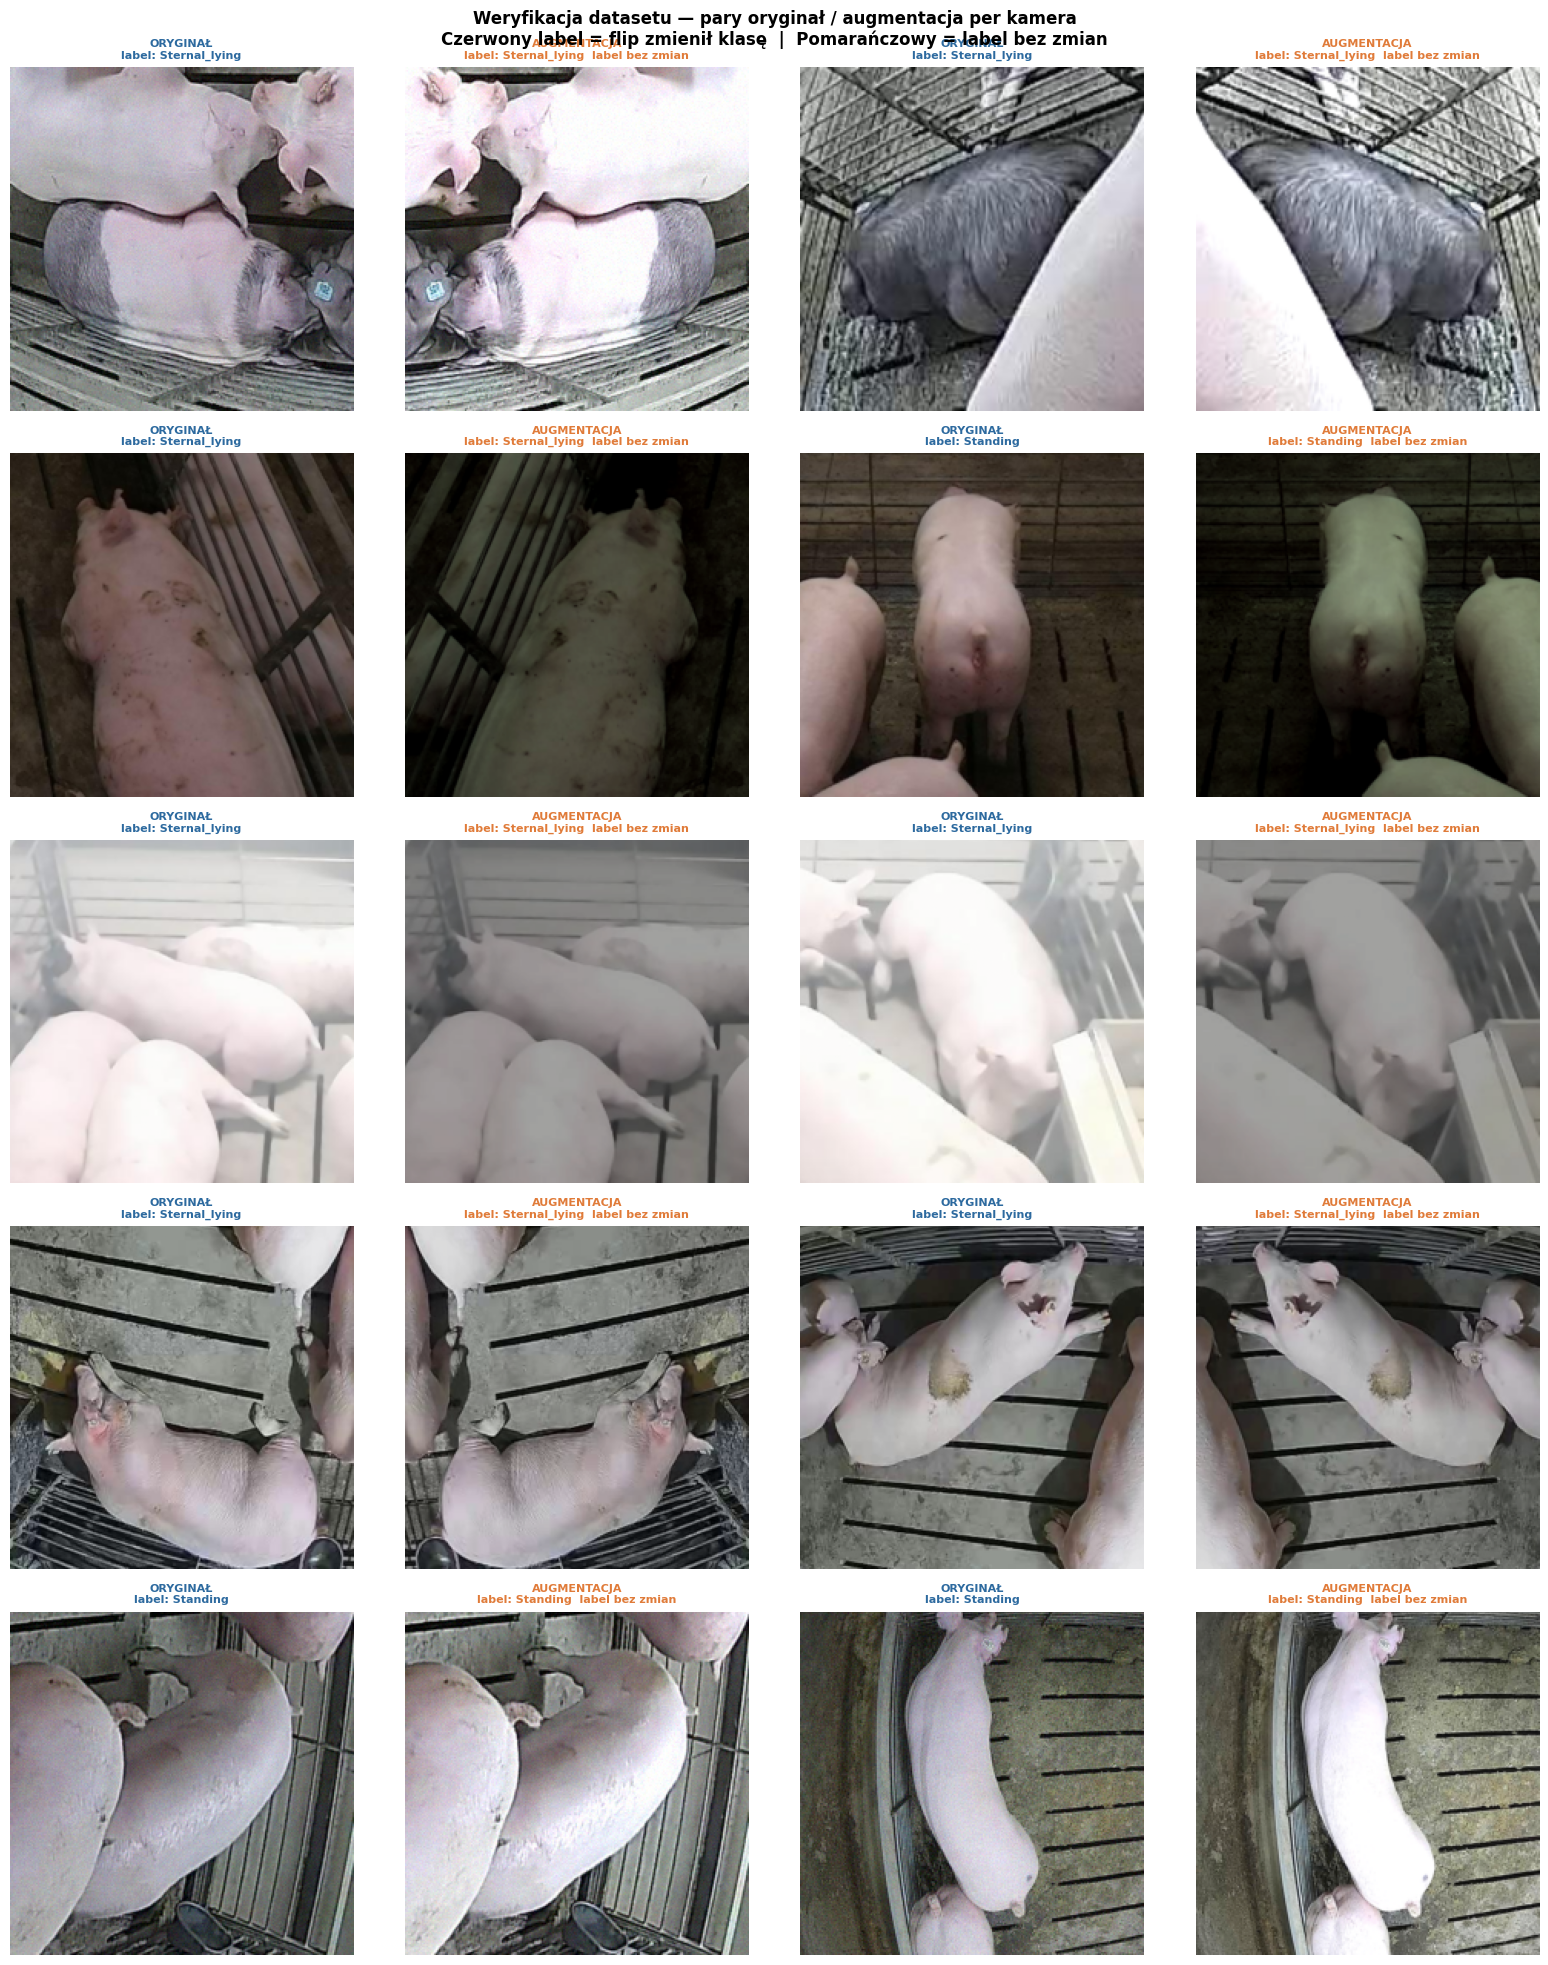

=== Podsumowanie datasetu ===
Kamera                  Oryg.     Aug.    Razem   flip_label
pen1_tur_cam2           8,194    8,194   16,388         True
pen2_orb_cam1           2,817    2,817    5,634         True
pen2_orb_cam2             120      120      240        False
pen2_tur_cam1           9,713    9,713   19,426         True
pen2_tur_cam2             196      196      392        False
(brak aug)              2,410        0    2,410        False

ŁĄCZNIE                44,490


In [ ]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)


def show_dataset_pairs(dataset, n_per_cam=2):
    """
    Dla każdej kamery z augmentacją pokazuje pary:
    oryginał (z datasetu) | zaugmentowana wersja (z datasetu)
    Weryfikuje że dataset poprawnie tworzy pary i zmienia labele.
    """
    # Grupujemy samples po kamerze i czy jest augmentowany
    cam_samples = {}
    for sample_idx, (row_idx, do_aug, label) in enumerate(dataset.samples):
        cam = dataset.df.iloc[row_idx]["camera"]
        if cam not in CAMERA_AUG_FN:
            continue
        if cam not in cam_samples:
            cam_samples[cam] = {"orig": [], "aug": []}
        if do_aug:
            cam_samples[cam]["aug"].append((sample_idx, label))
        else:
            cam_samples[cam]["orig"].append((sample_idx, label))

    n_cams = len(cam_samples)
    fig, axes = plt.subplots(
        n_cams, n_per_cam * 2,
        figsize=(4 * n_per_cam * 2, 4 * n_cams)
    )
    if n_cams == 1:
        axes = axes[np.newaxis, :]

    for row_i, (cam, samples) in enumerate(cam_samples.items()):
        _, flip_label = CAMERA_AUG_FN[cam]

        # Bierzemy n_per_cam losowych par (oryginał + aug mają ten sam row_idx)
        # Szukamy par po row_idx
        orig_by_rowidx = {dataset.samples[si][0]: (si, lbl)
                          for si, lbl in samples["orig"][:50]}
        aug_by_rowidx  = {dataset.samples[si][0]: (si, lbl)
                          for si, lbl in samples["aug"][:50]}

        # Wspólne row_idx
        common = list(set(orig_by_rowidx.keys()) & set(aug_by_rowidx.keys()))[:n_per_cam]

        for col_pair, row_idx in enumerate(common):
            orig_si, orig_lbl = orig_by_rowidx[row_idx]
            aug_si,  aug_lbl  = aug_by_rowidx[row_idx]

            img_orig = denormalize(dataset[orig_si][0]).permute(1, 2, 0).numpy()
            img_aug  = denormalize(dataset[aug_si][0]).permute(1, 2, 0).numpy()

            col_o = col_pair * 2
            col_a = col_pair * 2 + 1

            axes[row_i, col_o].imshow(img_orig)
            axes[row_i, col_o].axis("off")
            axes[row_i, col_o].set_title(
                f"ORYGINAŁ\nlabel: {CLASS_NAMES[orig_lbl]}",
                fontsize=8, color="#2d6a9f", fontweight="bold"
            )

            axes[row_i, col_a].imshow(img_aug)
            axes[row_i, col_a].axis("off")
            flip_note = f"→ {CLASS_NAMES[aug_lbl]}" if flip_label and orig_lbl != aug_lbl else "label bez zmian"
            axes[row_i, col_a].set_title(
                f"AUGMENTACJA\nlabel: {CLASS_NAMES[aug_lbl]}  {flip_note}",
                fontsize=8,
                color="#c44e52" if (flip_label and orig_lbl != aug_lbl) else "#e07b39",
                fontweight="bold"
            )

        # Etykieta kamery po lewej
        axes[row_i, 0].set_ylabel(
            f"{cam}\nflip={flip_label}",
            fontsize=9, fontweight="bold",
            color="#c44e52" if flip_label else "#55A868"
        )

    plt.suptitle(
        "Weryfikacja datasetu — pary oryginał / augmentacja per kamera\n"
        "Czerwony label = flip zmienił klasę  |  Pomarańczowy = label bez zmian",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig("dataset_pairs_verification.png", dpi=110, bbox_inches="tight")
    plt.show()

    # Podsumowanie tekstowe
    print("=== Podsumowanie datasetu ===")
    print(f"{'Kamera':20s} {'Oryg.':>8} {'Aug.':>8} {'Razem':>8} {'flip_label':>12}")
    for cam, samples in cam_samples.items():
        _, flip = CAMERA_AUG_FN[cam]
        n_orig = len(samples["orig"])
        n_aug  = len(samples["aug"])
        print(f"{cam:20s} {n_orig:>8,} {n_aug:>8,} {n_orig+n_aug:>8,} {str(flip):>12}")
    no_aug = len(train2) - sum(
        len(s["orig"]) for s in cam_samples.values()
    )
    print(f"{'(brak aug)':20s} {no_aug:>8,} {'0':>8} {no_aug:>8,} {'False':>12}")
    print(f"\n{'ŁĄCZNIE':20s} {len(dataset):>8,}")


show_dataset_pairs(train_dataset, n_per_cam=2)

In [ ]:
all_labels     = [s[2] for s in train_dataset.samples]
class_counts   = np.bincount(all_labels, minlength=NUM_CLASSES)
class_weights  = 1.0 / np.maximum(class_counts, 1)
sample_weights = np.array([class_weights[l] for l in all_labels])

print("Liczebność klas po augmentacji:", class_counts)

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print("DataLoader gotowy ✓")

Liczebność klas po augmentacji: [ 6272  6060  1358 19137 11663]
Train batches: 1391
DataLoader gotowy ✓


In [ ]:
import timm

MODEL_NAME = "convnextv2_base.fcmae_ft_in22k_in1k_224"

model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

print(f"ConvNeXt-V2 Base FCMAE | parametry: {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 160MB/s]


EfficientNetV2-S | parametry: 20,183,893


In [ ]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    n_batches = len(loader)

    for batch_i, (images, labels) in enumerate(loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        all_preds.extend(outputs.argmax(dim=1).detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        filled = int(30 * (batch_i + 1) / n_batches)
        bar    = "█" * filled + "░" * (30 - filled)
        pct    = 100 * (batch_i + 1) / n_batches
        print(f"\r  [train] |{bar}| {pct:5.1f}%  {batch_i+1}/{n_batches}"
              f"  loss={loss.item():.4f}", end="", flush=True)

    print()
    n = len(loader.dataset)
    return (total_loss / n,
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average="macro"))


best_f1, best_state, history = 0.0, None, []

for epoch in range(EPOCHS):
    # GPU check co 5 epok
    if epoch % 5 == 0 and DEVICE.type == "cuda":
        _x = torch.randn(10000, 10000, device=DEVICE)
        _t = time.time()
        _y = _x @ _x
        torch.cuda.synchronize()
        _e = time.time() - _t
        print(f"  [GPU check] {_e:.3f}s  {'✓' if _e < 1.0 else '⚠'}", flush=True)
        del _x, _y; torch.cuda.empty_cache()

    t0 = time.time()
    tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader)
    elapsed = time.time() - t0

    history.append({"epoch": epoch+1,
                    "train_loss": tr_loss, "train_acc": tr_acc, "train_f1": tr_f1})

    flag = "  ← best" if tr_f1 > best_f1 else ""
    print(f"Epoch {epoch+1:>2}/{EPOCHS} ({elapsed/60:.1f} min) | "
          f"loss {tr_loss:.4f}  acc {tr_acc:.4f}  f1 {tr_f1:.4f}"
          f"  lr {optimizer.param_groups[0]['lr']:.1e}{flag}", flush=True)

    # Scheduler na train f1 bo nie mamy val
    scheduler.step(tr_f1)

    if tr_f1 > best_f1:
        best_f1    = tr_f1
        best_state = copy.deepcopy(model.state_dict())
        torch.save({
            "model_state_dict": best_state,
            "class_names":      CLASS_NAMES,
            "best_train_f1":    best_f1,
            "epoch":            epoch + 1,
        }, SAVE_PATH)
        print(f"  💾 Zapisano → {SAVE_PATH}", flush=True)

print(f"\nNajlepsze train macro-F1: {best_f1:.4f}")

from google.colab import files
files.download(SAVE_PATH)
print(f"Model pobrany ✓")

  [GPU check] 0.546s  ✓
  [train] |██████████████████████████████| 100.0%  1391/1391  loss=0.0235
Epoch  1/6 (13.5 min) | loss 0.3406  acc 0.8749  f1 0.8749  lr 1.0e-04  ← best
  💾 Zapisano → T2_effnetv2_camera_aug.pt
  [train] |██████████████████████████████| 100.0%  1391/1391  loss=0.6182
Epoch  2/6 (13.1 min) | loss 0.1031  acc 0.9667  f1 0.9665  lr 1.0e-04  ← best
  💾 Zapisano → T2_effnetv2_camera_aug.pt
  [train] |██████████████████████████████| 100.0%  1391/1391  loss=0.2318
Epoch  3/6 (13.2 min) | loss 0.0716  acc 0.9780  f1 0.9780  lr 1.0e-04  ← best
  💾 Zapisano → T2_effnetv2_camera_aug.pt
  [train] |██████████████████████████████| 100.0%  1391/1391  loss=0.0307
Epoch  4/6 (13.1 min) | loss 0.0548  acc 0.9837  f1 0.9837  lr 1.0e-04  ← best
  💾 Zapisano → T2_effnetv2_camera_aug.pt
  [train] |██████████████████████████████| 100.0%  1391/1391  loss=0.6535
Epoch  5/6 (13.1 min) | loss 0.0434  acc 0.9871  f1 0.9871  lr 1.0e-04  ← best
  💾 Zapisano → T2_effnetv2_camera_aug.pt
  [GPU

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model pobrany ✓


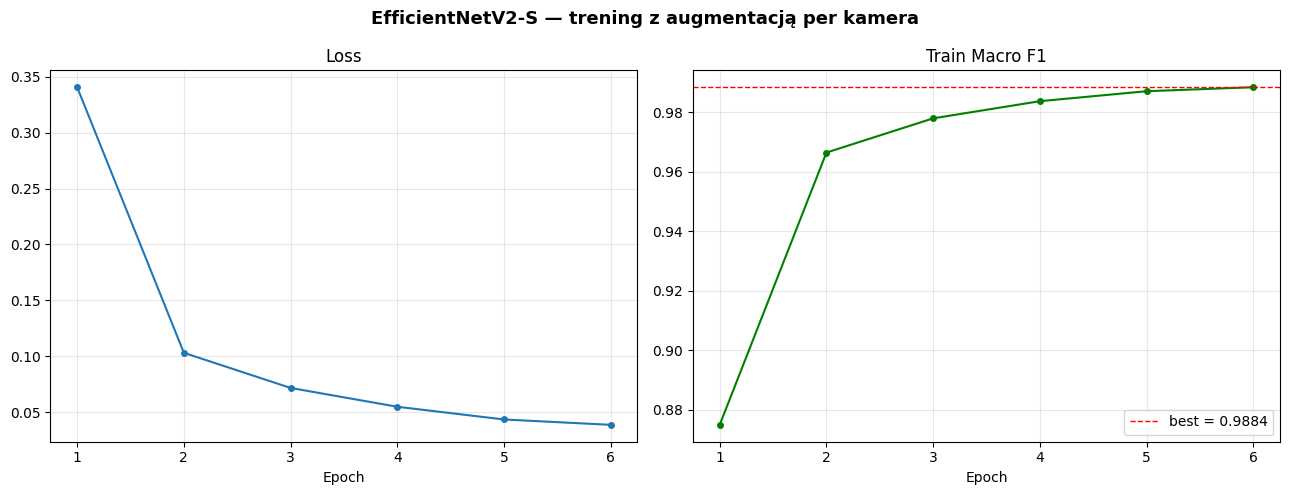

In [ ]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(hist_df["epoch"], hist_df["train_loss"], marker="o", markersize=4)
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=0.3)

axes[1].plot(hist_df["epoch"], hist_df["train_f1"], marker="o", markersize=4, color="green")
axes[1].axhline(best_f1, color="red", linestyle="--", linewidth=1,
                label=f"best = {best_f1:.4f}")
axes[1].set_title("Train Macro F1"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("ConvNeXt-V2 Base FCMAE — trening z augmentacją per kamera",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Wczytanie najlepszego modelu ──────────────────────────────────────────────
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Model wczytany ✓  (train F1: {checkpoint['best_train_f1']:.4f}, "
      f"epoch: {checkpoint['epoch']})")

# ── Wczytanie test CSV ────────────────────────────────────────────────────────
test = pd.read_csv(BASE_DIR / "test.csv")
test["source"]      = "test"
test["bbox_parsed"] = test["bbox"].apply(ast.literal_eval)

print(f"Test: {len(test):,} obserwacji  |  {test['image_id'].nunique():,} zdjęć")

# ── Dataset i loader testowy ──────────────────────────────────────────────────
class PigTestDataset(Dataset):
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = load_image(row["image_id"], row["source"])
        crop  = crop_with_padding(image, row["bbox_parsed"],
                                  padding=0.12, make_square=True)
        crop  = self.transform(crop)
        return crop, row["row_id"]


test_loader = DataLoader(
    PigTestDataset(test, VAL_TRANSFORM),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ── Inferencja ────────────────────────────────────────────────────────────────
all_row_ids = []
all_preds   = []

model.eval()
with torch.no_grad():
    for batch_i, (images, row_ids) in enumerate(test_loader):
        images  = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()

        all_row_ids.extend(row_ids)
        all_preds.extend(preds)

        filled = int(30 * (batch_i + 1) / len(test_loader))
        bar    = "█" * filled + "░" * (30 - filled)
        pct    = 100 * (batch_i + 1) / len(test_loader)
        print(f"\r  [test] |{bar}| {pct:5.1f}%  {batch_i+1}/{len(test_loader)}",
              end="", flush=True)

print(f"\nInferencja zakończona: {len(all_preds):,} predykcji")

# ── Budowanie pliku submisji ──────────────────────────────────────────────────
submission = pd.DataFrame({
    "row_id":   all_row_ids,
    "class_id": all_preds
})

# Weryfikacja formatu
sample_sub = pd.read_csv(BASE_DIR / "sample_submission.csv")
assert set(submission["row_id"]) == set(sample_sub["row_id"]), \
    "Niezgodne row_id z sample_submission!"
assert submission["class_id"].between(0, 4).all(), \
    "Błędne wartości class_id (oczekiwane 0-4)!"

# Sortujemy tak jak sample_submission
submission = submission.set_index("row_id").reindex(sample_sub["row_id"]).reset_index()

print(f"\nRozkład predykcji:")
for cid, cnt in sorted(submission["class_id"].value_counts().items()):
    print(f"  [{cid}] {CLASS_NAMES[cid]:25s}: {cnt:,}  ({cnt/len(submission)*100:.1f}%)")

# ── Zapis i pobranie ──────────────────────────────────────────────────────────
SUBMISSION_PATH = "submission_T2_camera_convnext.csv"
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"\nZapisano → {SUBMISSION_PATH}")
print(submission.head(10).to_string())

files.download(SUBMISSION_PATH)
print("Plik pobrany ✓")

Model wczytany ✓  (train F1: 0.9884, epoch: 6)
Test: 11,708 obserwacji  |  1,350 zdjęć
  [test] |██████████████████████████████| 100.0%  366/366
Inferencja zakończona: 11,708 predykcji

Rozkład predykcji:
  [0] Lateral_lying_left       : 1,120  (9.6%)
  [1] Lateral_lying_right      : 1,063  (9.1%)
  [2] Sitting                  : 541  (4.6%)
  [3] Standing                 : 6,835  (58.4%)
  [4] Sternal_lying            : 2,149  (18.4%)

Zapisano → submission_T2_camera_aug.csv
                                    row_id  class_id
0  test_pen1_tur_cam1_20250920_174649_0000         3
1  test_pen1_tur_cam1_20250920_174649_0001         3
2  test_pen1_tur_cam1_20250920_174649_0002         0
3  test_pen1_tur_cam1_20250920_174649_0003         3
4  test_pen1_tur_cam1_20250920_174649_0004         0
5  test_pen1_tur_cam1_20250920_174649_0005         1
6  test_pen1_tur_cam1_20250920_174649_0006         1
7  test_pen1_tur_cam1_20250920_174649_0007         4
8  test_pen1_tur_cam1_20250920_174649_0008

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Plik pobrany ✓
